# Project Work NLP: Analisi della Distorsione e Omogeneizzazione della Scrittura da parte degli LLM

Questo notebook esplora l'impatto dei Modelli Linguistici di Grandi Dimensioni (LLM) sulla scrittura umana, implementando un'analisi basata su due recenti studi:

1. L'analisi di *"How LLMs Distort Our Written Language"* (2026), che dimostra come l'uso dell'IA come co-pilota di scrittura tenda a cancellare l'identità dell'autore, generando una "voce algoritmica" omogeneizzata.
2. L'indagine di *"Scientific production in the era of large language models"* (Science, 2025), che evidenzia come l'IA alteri la complessità linguistica spingendo verso un linguaggio iper-formale e artificiale.

Al fine di approfondire sperimentalmente i risultati emersi, questo project work è organizzato in tre esperimenti, ognuno dedicato all'analisi di uno specifico effetto degli LLM sulla produzione testuale.

* **Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche:** analisi di come varia la prevedibilità statistica e la complessità strutturale del testo passando dalla bozza umana iniziale, alla revisione manuale, fino alla revisione artificiale (utilizzando il dataset *ArgRewrite*).
* **Esperimento 2 - Classificazione con Bag of Words e DistilBERT:** analisi delle firme stilistiche dell'IA attraverso due approcci di classificazione: uno basato sulla rappresentazione Bag of Words (BoW) e un classificatore tradizionale, e uno basato sul modello Transformer *DistilBERT*.
* **Esperimento 3 - Omogeneizzazione Lessicale e Sintattica:** replicazione riguardo alla parte di metodologia applicata alle recensioni *ICLR 2026* per misurare la perdita di varietà del vocabolario (tramite Type-Token Ratio) confrontando testi puramente umani e testi generati da IA su un dataset indipendente.

---

### Configurazione dell'Ambiente e Importazione delle Librerie
In questa cella viene configurato l'ambiente importando i pacchetti necessari per la manipolazione dei dati (`pandas`, `numpy`), la visualizzazione grafica (`matplotlib`, `seaborn`), l'estrazione di feature tradizionali e la modellazione classica (`scikit-learn`), e il calcolo delle metriche linguistiche avanzate (`transformers`, `nltk`, `textstat`, `sentence-transformers`).

In [49]:
import os
import re
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import nltk
import textstat

from nltk.tokenize import sent_tokenize, word_tokenize
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    GPT2LMHeadModel, 
    GPT2Tokenizer, 
    DistilBertTokenizer, 
    DistilBertForSequenceClassification
)

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from IPython.display import display, Markdown

# Download risorse NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Impostazioni grafiche
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

### Caricamento e Strutturazione dei Dati

Prima di estrarre le metriche linguistiche, strutturiamo il dataset in modo da allineare ogni singolo saggio lungo il suo ciclo vitale. 

Attraverso l'integrazione del corpus **ArgRewrite V.2** (per i testi umani) e delle riscritture contenute in `dataframe_essays_llm_model.csv` (per i modelli generativi), costruiamo un unico DataFrame unificato (`df_timeline`).

Nello specifico, il dataset comprende **86 saggi umani unici**, ciascuno affiancato a 30 riscritture IA differenti (derivate da più modelli e prompt). Ciascuna riga del DataFrame allinea il percorso evolutivo su tre stadi:

1. **$t_0$ - Bozza Iniziale**: il testo grezzo scritto dallo studente prima di ricevere feedback (`Draft1`).
2. **$t_1$ - Revisione Umana**: l'evoluzione naturale del saggio rivista dallo studente a seguito dei commenti (`Draft2`).
3. **$t_1^*$ - Riscrittura IA**: la revisione parallela generata da LLM di riferimento a partire dalla bozza $t_0$.

Per evitare distorsioni nelle analisi descrittive dei testi umani (dovute alla ripetizione dei testi $t_0$ e $t_1$ sulle 30 varianti IA), isoliamo un sottoinsieme deduplicato composto dai soli 86 saggi umani unici (`df_umani_unici`). Questo allineamento ci permetterà di confrontare direttamente la traiettoria evolutiva della scrittura umana contro la traiettoria di riscrittura dell'IA.

In [ ]:
PATH_ANALYSIS = "./data/argrewrite_analysis"
csv_real_path = os.path.join(PATH_ANALYSIS, "dataframe_essays_llm_model.csv")

if os.path.exists(csv_real_path):
    df_raw = pd.read_csv(csv_real_path)
    
    modelli_disponibili = df_raw["llm_model"].unique()
    print(f"[DATA] Modelli LLM presenti nel dataset: {list(modelli_disponibili)}")

    df_filtered = df_raw.copy()
    
    # costruzione del DataFrame
    df_timeline = pd.DataFrame({
        "essay_id": df_filtered["essay_id"],
        "t0_bozza": df_filtered["draft1"],
        "t1_umano": df_filtered["draft2"],
        "t1_ia": df_filtered["ai_text"],
        "llm_model": df_filtered["llm_model"]
    }).dropna().reset_index(drop=True)
    
    df_umani_unici = df_timeline.drop_duplicates(subset=["essay_id"]).reset_index(drop=True)
    
    print(f"[DATA] Caricamento completato con successo.")
    print(f"[DATA] Totale righe dataset (varianti IA comprese): {len(df_timeline)}")
    print(f"[DATA] Totale saggi umani unici (essay_id): {df_umani_unici['essay_id'].nunique()}")
else:
    raise FileNotFoundError(f"Impossibile trovare il file: {csv_real_path}")

[DATA] Modelli LLM presenti nel dataset: ['CLAUDE-HAIKU-4-5-20251001', 'GPT-5-MINI', 'GEMINI-2.5-FLASH']
[DATA] Caricamento completato con successo.
[DATA] Totale righe dataset (varianti IA comprese): 2580
[DATA] Totale saggi umani unici (essay_id): 86


---

## Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche

### Obiettivo
In questo primo esperimento misuriamo come si trasforma l'impronta stilistica di un testo durante il suo processo di revisione. La letteratura scientifica suggerisce che l'intervento di un LLM tenda ad "appiattire" il testo, rendendolo più prevedibile e strutturalmente monotono, aumentandone però la complessità sintattica e lessicale.

Analizzeremo l'evoluzione delle grandezze testuali confrontando tre fasi temporali distinte:

1. **$t_0$ - Bozza Iniziale:** il saggio originale scritto dallo studente.
2. **$t_1$ - Revisione Manuale:** il saggio corretto dallo studente seguendo il feedback del docente.
3. **$t_1^*$ - Riscrittura IA:** il saggio originale fatto correggere a un modello IA.

### Metriche Calcolate e Parametri di Elaborazione
Per tracciare questa evoluzione estrarremo quattro grandezze fondamentali:

* **Entropia:** misura il grado di incertezza del modello nel prevedere la parola successiva. Nello specifico, è calcolata come cross-entropy loss utilizzando il modello base GPT-2. Testi fortemente standardizzati dall'IA presentano un'entropia minore.
* **Perplessità:** direttamente derivata dall'entropia, indica quanto il testo sia "sorprendente" per un modello linguistico:
  $$Perplexity = \exp(Entropy)$$
* **Burstiness:** valuta la varianza nella lunghezza delle frasi. Gli esseri umani alternano frasi brevi e lunghe (alta burstiness), mentre l'IA tende a produrre strutture di lunghezza uniforme. È calcolata tramite la deviazione standard del numero di parole per frase.
* **Leggibilità Flesch:** un indice per quantificare la facilità di lettura basato su sillabe e lunghezza delle parole. L'obiettivo è verificare se la revisione dell'IA introduca una complessità sintattica artificiale rispetto alla revisione umana.

> **Nota Metodologica (512 Token):** L'analisi è limitata ai primi 512 token per saggio (`max_length=512`) per rispettare i vincoli di memoria hardware di elaborazione CPU e garantire un confronto omogeneo tra i testi.

### Estrattore Metriche Linguistiche

L'estrazione viene eseguita in modalità vettorializzata e isolata: per gli stadi $t_0$ e $t_1$ le metriche vengono calcolate esclusivamente sull'insieme unico dei 86 saggi umani per poi essere mappate nel DataFrame generale, mentre per $t_1^*$ vengono elaborate tutte le 2580 riscritture IA.

In [52]:
device = "cpu"

print("=" * 70)
print("ESPERIMENTO 1: CALCOLO DELLE METRICHE LINGUISTICHE")
print("=" * 70)
print(f"Dispositivo in uso: {device.upper()}")

# Inizializzazione GPT-2 per entropia e perplessità
gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt_model.eval()

def calcola_entropia_perplessita(testo):
    if not isinstance(testo, str) or not testo.strip():
        return np.nan, np.nan
    
    inputs = gpt_tokenizer(testo, return_tensors="pt", truncation=True, max_length=512).to(device)
    if inputs.input_ids.shape[1] < 2:
        return np.nan, np.nan
        
    with torch.no_grad():
        outputs = gpt_model(inputs.input_ids, labels=inputs.input_ids)
        loss = outputs.loss.item()
        perplexity = float(np.exp(loss))
        
    return loss, perplexity

stadi = [
    ("t0", "t0_bozza", "$t_0$ Bozza Umana", True),
    ("t1_h", "t1_umano", "$t_1$ Revisione Umana", True),
    ("t1_ai", "t1_ia", "$t_1^*$ Riscrittura IA", False)
]

for prefisso, col_testo, nome_stadio, usa_unici in stadi:
    df_target = df_umani_unici if usa_unici else df_timeline
    totale = len(df_target)
    
    print(f"\n[{nome_stadio}] Processamento su {totale} testi...")
    entropie, perplessita, burstiness, leggibilita = [], [], [], []
    
    for i, row in enumerate(df_target.itertuples(), start=1):
        testo = getattr(row, col_testo)
        e, p = calcola_entropia_perplessita(testo)
        
        # burstiness e leggibilità
        if isinstance(testo, str) and testo.strip():
            frasi = nltk.sent_tokenize(testo)
            b = (float(np.std([len(nltk.word_tokenize(f)) for f in frasi])) if len(frasi) > 1 else 0.0)
            l = textstat.flesch_reading_ease(testo)
        else:
            b, l = 0.0, np.nan
            
        entropie.append(e)
        perplessita.append(p)
        burstiness.append(b)
        leggibilita.append(l)
        
        if i % 10 == 0 or i == totale:
            print(f"  Progressione: {i:>4}/{totale} ({i/totale*100:5.1f}%)", end="\r")
    
    # assegnazione dei risultati
    if usa_unici:
        df_umani_unici[f"{prefisso}_entropy"] = entropie
        df_umani_unici[f"{prefisso}_perplexity"] = perplessita
        df_umani_unici[f"{prefisso}_burstiness"] = burstiness
        df_umani_unici[f"{prefisso}_readability"] = leggibilita
        
        # mappiamo su df_timeline usando l'essay_id come chiave
        for metrica in ["entropy", "perplexity", "burstiness", "readability"]:
            mapping = dict(zip(df_umani_unici["essay_id"], df_umani_unici[f"{prefisso}_{metrica}"]))
            df_timeline[f"{prefisso}_{metrica}"] = df_timeline["essay_id"].map(mapping)
    else:
        # IA assegniamo direttamente a df_timeline
        df_timeline[f"{prefisso}_entropy"] = entropie
        df_timeline[f"{prefisso}_perplexity"] = perplessita
        df_timeline[f"{prefisso}_burstiness"] = burstiness
        df_timeline[f"{prefisso}_readability"] = leggibilita
        
    print(f"\n  Completato per {nome_stadio}")

torch.cuda.empty_cache()

ESPERIMENTO 1: CALCOLO DELLE METRICHE LINGUISTICHE
Dispositivo in uso: CPU


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


[$t_0$ Bozza Umana] Processamento su 86 testi...
  Progressione:   86/86 (100.0%)
  Completato per $t_0$ Bozza Umana

[$t_1$ Revisione Umana] Processamento su 86 testi...
  Progressione:   86/86 (100.0%)
  Completato per $t_1$ Revisione Umana

[$t_1^*$ Riscrittura IA] Processamento su 2580 testi...
  Progressione: 2580/2580 (100.0%)
  Completato per $t_1^*$ Riscrittura IA


### Visualizzazione Grafica comparativa

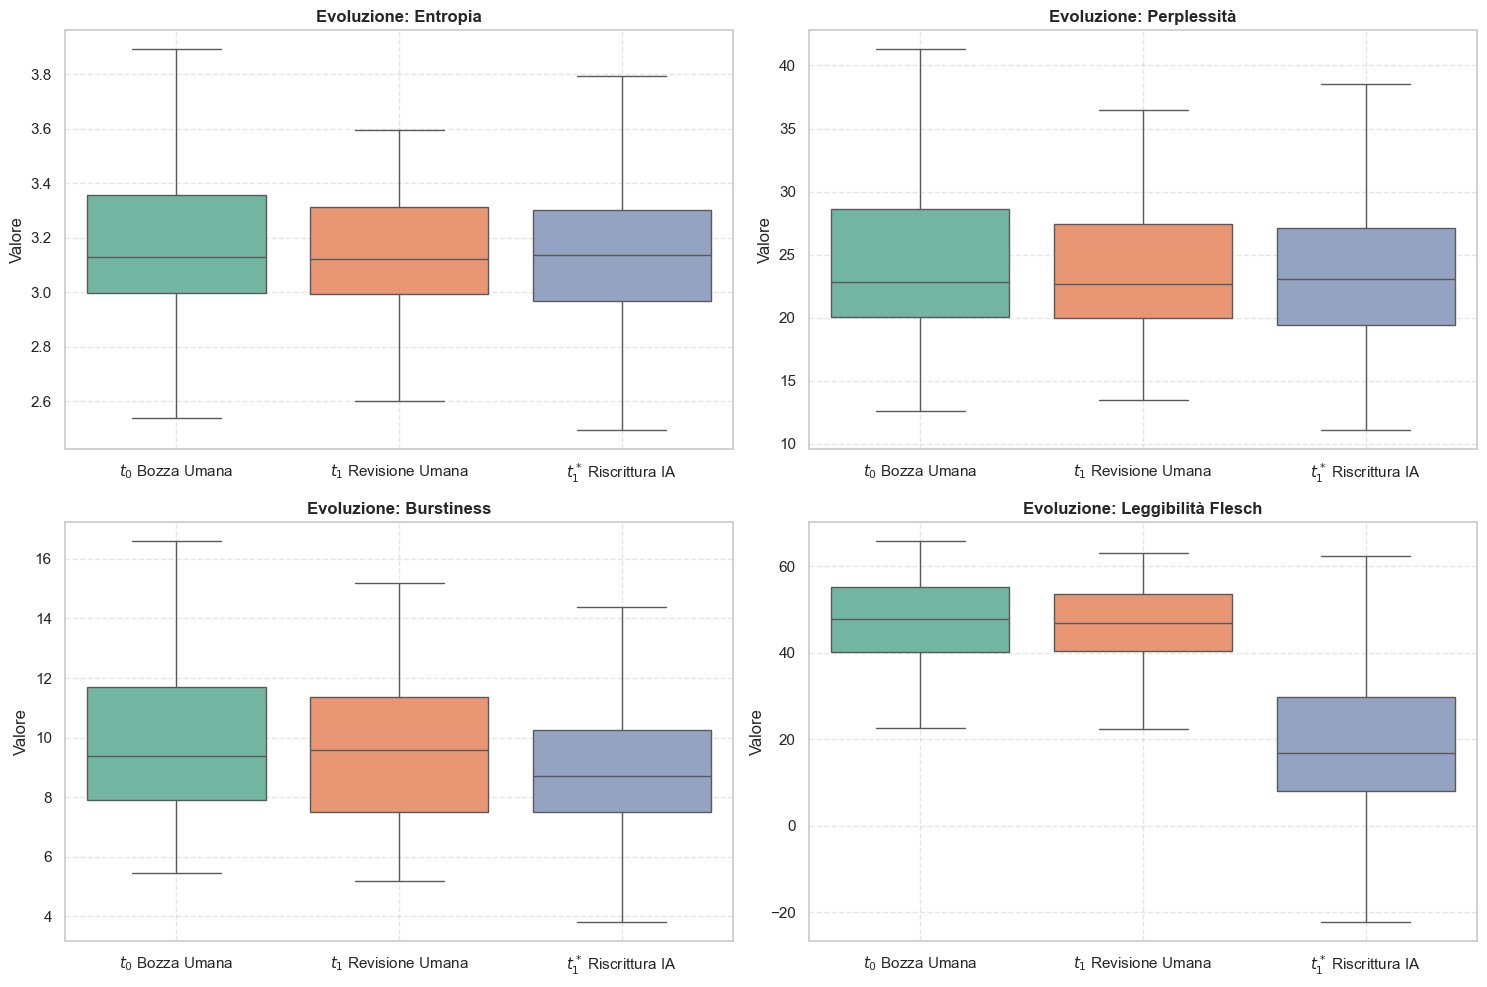

In [58]:
metrics_to_plot = [
    ("entropy", "Entropia"),
    ("perplexity", "Perplessità"),
    ("burstiness", "Burstiness"),
    ("readability", "Leggibilità Flesch")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (metric_code, metric_name) in enumerate(metrics_to_plot):
    df_t0 = pd.DataFrame({"Stadio": "$t_0$ Bozza Umana", "Valore": df_umani_unici[f"t0_{metric_code}"]})
    df_t1_h = pd.DataFrame({"Stadio": "$t_1$ Revisione Umana", "Valore": df_umani_unici[f"t1_h_{metric_code}"]})
    df_t1_ai = pd.DataFrame({"Stadio": "$t_1^*$ Riscrittura IA", "Valore": df_timeline[f"t1_ai_{metric_code}"]})
    
    df_plot = pd.concat([df_t0, df_t1_h, df_t1_ai], ignore_index=True)
    
    sns.boxplot(
        data=df_plot, 
        x="Stadio", 
        y="Valore", 
        ax=axes[idx], 
        palette="Set2", 
        hue="Stadio", 
        legend=False,
        showfliers=False
    )
    
    axes[idx].set_title(f"Evoluzione: {metric_name}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Valore")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Risultati del Grafico**

I quattro boxplot mostrano una differenza evidente tra $t_1$ e $t_1^*$. La correzione umana mantiene caratteristiche del tutto simili al testo originale ($t_0$), mentre l’IA modifica in modo sostanziale la struttura del testo.

* **Perplessità ed Entropia:** le mediane rimangono stabili in tutte e tre le fasi. Tuttavia, nel testo riscritto dall’IA ($t_1^*$), i valori risultano **più concentrati** (minore deviazione standard), indicando una maggiore standardizzazione stilistica e una ridotta variabilità.
* **Burstiness:** in $t_1^*$ diminuisce sia la media/mediana che la dispersione nella lunghezza delle frasi. Le strutture sintattiche risultano più omogenee tra loro e il testo assume un ritmo più uniforme rispetto a $t_0$ e $t_1$.
* **Leggibilità Flesch:** è il cambiamento più evidente. La mediana di $t_1^*$ crolla sotto 20, mostrando che il testo prodotto dall’IA è molto più difficile da leggere rispetto alla stesura umana, a causa dell'uso di costrutti sintattici e lessicali più complessi e formali.

In generale, i dati evidenziano che l’IA non si limita a perfezionare il testo originale, ma ne trasforma lo stile: ne uniforma il ritmo, ne stabilizza la prevedibilità probabilistica e ne incrementa sensibilmente la complessità sintattica.

### Tabella Riassuntiva delle Medie e Deviazioni Standard

In [59]:
def fmt_stats(series):
    return f"{series.mean():.2f} ± {series.std():.2f}"

metriche_summary = {
    "Stadio": ["$t_0$ - Bozza Umana", "$t_1$ - Revisione Umana", "$t_1^*$ - Riscrittura IA"],
    "Entropy (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_entropy']),
        fmt_stats(df_umani_unici['t1_h_entropy']),
        fmt_stats(df_timeline['t1_ai_entropy'])
    ],
    "Perplexity (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_perplexity']),
        fmt_stats(df_umani_unici['t1_h_perplexity']),
        fmt_stats(df_timeline['t1_ai_perplexity'])
    ],
    "Burstiness (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_burstiness']),
        fmt_stats(df_umani_unici['t1_h_burstiness']),
        fmt_stats(df_timeline['t1_ai_burstiness'])
    ],
    "Leggibilità Flesch (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_readability']),
        fmt_stats(df_umani_unici['t1_h_readability']),
        fmt_stats(df_timeline['t1_ai_readability'])
    ]
}

df_summary = pd.DataFrame(metriche_summary)
display(Markdown(df_summary.to_markdown(index=False)))

| Stadio                   | Entropy (Media ± Std)   | Perplexity (Media ± Std)   | Burstiness (Media ± Std)   | Leggibilità Flesch (Media ± Std)   |
|:-------------------------|:------------------------|:---------------------------|:---------------------------|:-----------------------------------|
| $t_0$ - Bozza Umana      | 3.18 ± 0.29             | 25.18 ± 8.12               | 10.28 ± 3.35               | 47.09 ± 9.75                       |
| $t_1$ - Revisione Umana  | 3.15 ± 0.28             | 24.21 ± 7.60               | 10.01 ± 3.42               | 46.14 ± 9.42                       |
| $t_1^*$ - Riscrittura IA | 3.13 ± 0.24             | 23.62 ± 5.64               | 9.05 ± 2.30                | 19.58 ± 15.23                      |

**Analisi della Tabella Riassuntiva**

* **Revisione Umana ($t_0 \rightarrow t_1$):** l'intervento umano mantiene inalterata l'impronta stilistica. La perplessità passa da $25.18 ± 8.12$ a $24.21 ± 7.60$, l'entropia da $3.18 ± 0.29$ a $3.15 ± 0.28$, la burstiness da $10.28 ± 3.35$ a $10.01 ± 3.42$ e la leggibilità da $47.09 ± 9.75$ a $46.14 ± 9.42$.
* **Riscrittura IA ($t_1^*$):** l'IA rende il testo più prevedibile e strutturalmente uniforme. Si osserva un ridimensionamento sia delle medie che delle deviazioni standard per entropia ($3.13 ± 0.24$), perplessità ($23.62 ± 5.64v) e burstiness ($9.05 ± 2.30$). La contrazione della deviazione standard in queste tre metriche conferma un chiaro effetto di "appiattimento" stilistico.
* **Esplosione della Varianza nella Leggibilità:** il cambiamento più evidente riguarda la leggibilità Flesch: la media crolla a $19.58$, mentre la deviazione standard aumenta fino a $± 15.23$ (un incremento del **+61,7%** rispetto alla deviazione standard della revisione umana $t_1$). A differenza delle altre metriche, l'IA non uniforma la leggibilità, ma ne amplifica la dispersione, alternando riscritture estremamente complesse ad altre più lineari.

### Conclusioni Esperimento 1

L'analisi condotta sui **2.580 testi** evidenzia una netta divaricazione tra la scrittura dei testi umani e quello dei modelli generativi:

1. **Gli umani preservano l'identità stilistica ($t_0 \rightarrow t_1$):** la revisione dello studente affina la forma senza alterare il ritmo, la leggibilità o la distribuzione delle strutture sintattiche.
2. **L'IA appiattisce il ritmo e complica la struttura ($t_0 \rightarrow t_1^*$):** la riscrittura IA uniforma la prevedibilità e riduce l'alternanza nella lunghezza delle frasi (cioè minor burstiness), provocando però un forte degrado della leggibilità e un'elevata instabilità nella complessità sintattica.

Tali risultati costituiscono il presupposto per l'**Esperimento 2**, in cui valuteremo la capacità dei modelli di ML di rilevare automaticamente le riscritture sintetiche basandosi su queste caratteristiche attraverso la classificazione.

---

## Esperimento 2 - Classificazione con Bag of Words e DistilBERT

### Obiettivo
Questo esperimento ha lo scopo di verificare se le impronte stilistiche lasciate dall'IA ($t_1^*$) siano sufficientemente distinte rispetto al testo scritto dall'umano da permettere a un classificatore di individuarle su saggi non visti in fase di addestramento.

Il task di classificazione multiclasse si articola su tre categorie:

* **Classe 0 ($t_0$)**: bozza iniziale dello studente.
* **Classe 1 ($t_1$)**: revisione manuale dello studente.
* **Classe 2 ($t_1^*$)**: riscrittura eseguita dall'IA.

### Architettura e Metodologia
1. **Costruzione del Dataset e prevenzione Group Leakage**: riorganizzazione del formato dei dati e partizione tra Train Set (80%) e Test Set (20% — 1.620 campioni). La suddivisione viene eseguita tramite `GroupShuffleSplit` su *essay_id* per garantire di non avere sovrapposizione tra i saggi dei due split.
3. **Parte 1 - Classificazione Avanzata (Fine-Tuning di DistilBERT)**: addestramento del modello Transformer `distilbert-base-uncased` tramite PyTorch per catturare le relazioni contestuali e sintattiche. La sequenza viene limitata a 128 token (max_len=128) per rispettare i vincoli di memoria hardware.
4. **Parte 2 - Baseline Frequenziali (Bag of Words e TF-IDF)**: Vettorializzazione del testo completo tramite n-grammi per misurare la discriminabilità basata sulla frequenza dei termini:
    * **Bag of Words (BoW)** con unigrammi e bigrammi.
    * **TF-IDF Ricalibrato** limitato ai soli unigrammi.
5. **Valutazione e Confronto**: analisi comparativa di Accuratezza, Precision, Recall, F1-Score e Matrice di Confusione per tutti gli approcci.

### Implementazione Codice

#### Parte 1: Classificazione Avanzata con DistilBERT

##### 1. Preparazione Dataset e Dataloader

In [42]:
device_exp2 = torch.device("cpu")
print(f"[INFO] Dispositivo selezionato per l'Esperimento 2: {device_exp2}")

gc.collect()

print("=" * 70)
print("ESPERIMENTO 2: CLASSIFICAZIONE")
print("=" * 70)

# raggreuppo su essay_id
df_t0    = pd.DataFrame({"text": df_timeline["t0_bozza"],  "label": 0, "essay_id": df_timeline["essay_id"]})
df_t1_h  = pd.DataFrame({"text": df_timeline["t1_umano"],  "label": 1, "essay_id": df_timeline["essay_id"]})
df_t1_ai = pd.DataFrame({"text": df_timeline["t1_ia"],     "label": 2, "essay_id": df_timeline["essay_id"]})

df_classification = pd.concat([df_t0, df_t1_h, df_t1_ai], ignore_index=True).dropna()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_classification, groups=df_classification["essay_id"]))

train_df = df_classification.iloc[train_idx]
test_df  = df_classification.iloc[test_idx]

X_train, y_train = train_df["text"].to_numpy(), train_df["label"].to_numpy()
X_test,  y_test   = test_df["text"].to_numpy(),  test_df["label"].to_numpy()

overlap = set(train_df["essay_id"]).intersection(set(test_df["essay_id"]))

print(f"[INFO] Campioni di Training: {len(X_train)}")
print(f"[INFO] Campioni di Test:     {len(X_test)}")
print(f"[INFO] Saggi unici Train: {train_df['essay_id'].nunique()} | Test: {test_df['essay_id'].nunique()}")
print(f"[INFO] Overlap essay_id Train/Test: {len(overlap)}")

[INFO] Dispositivo selezionato per l'Esperimento 2: cpu
ESPERIMENTO 2: CLASSIFICAZIONE
[INFO] Campioni di Training: 6120
[INFO] Campioni di Test:     1620
[INFO] Saggi unici Train: 68 | Test: 18
[INFO] Overlap essay_id Train/Test: 0


In [38]:
# PyTorch Dataset
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(self.labels[item], dtype=torch.long)
        }

bert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_dataset = TextClassificationDataset(X_train, y_train, bert_tokenizer, max_len=128)
test_dataset = TextClassificationDataset(X_test, y_test, bert_tokenizer, max_len=128)

# size batch ottimizzati per CPU multi-core
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##### 2. Inizializzazione, Fine-Tuning e Valutazione DistilBERT

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[BERT] Avvio Addestramento su CPU...
  Epoch 1/3 | Batch 383/383 | Loss: 0.1135
  Epoch 1 completata. Loss Media: 0.5964
  Epoch 2/3 | Batch 383/383 | Loss: 0.3886
  Epoch 2 completata. Loss Media: 0.2419
  Epoch 3/3 | Batch 383/383 | Loss: 0.2031
  Epoch 3 completata. Loss Media: 0.2013

REPORT DI CLASSIFICAZIONE BERT
                    precision    recall  f1-score   support

    t0 Bozza Umana       0.64      0.11      0.19       540
t1 Revisione Umana       0.47      0.39      0.43       540
t1* Riscrittura IA       0.47      0.94      0.63       540

          accuracy                           0.48      1620
         macro avg       0.53      0.48      0.41      1620
      weighted avg       0.53      0.48      0.41      1620



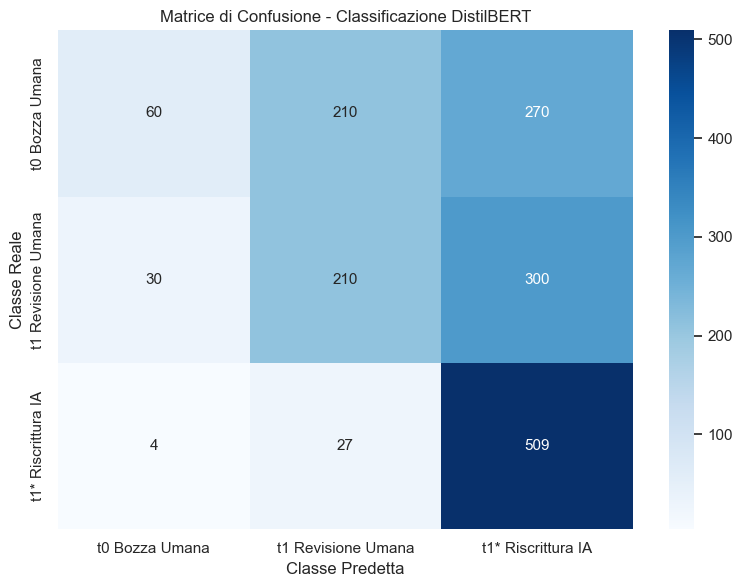

In [39]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=3
).to(device_exp2)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)
epochs = 3

# training Loop
print("\n[BERT] Avvio Addestramento su CPU...")
for epoch in range(epochs):
    bert_model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(device_exp2)
        attention_mask = batch["attention_mask"].to(device_exp2)
        labels = batch["label"].to(device_exp2)
        
        outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        # monitoro avanazamento
        if batch_idx % 50 == 0 or batch_idx == len(train_loader):
            print(f"  Epoch {epoch+1}/{epochs} | Batch {batch_idx:>3}/{len(train_loader)} | Loss: {loss.item():.4f}", end="\r")
            
    print(f"\n  Epoch {epoch+1} completata. Loss Media: {total_loss/len(train_loader):.4f}")

# valutazione metriche
bert_model.eval()
# liste predizioni e etichette reali
y_preds = []
y_trues = []

# disabilito calcolo gradienti
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device_exp2)
        attention_mask = batch["attention_mask"].to(device_exp2)
        labels = batch["label"].to(device_exp2)
        
        outputs = bert_model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        y_preds.extend(preds.cpu().numpy())
        y_trues.extend(labels.cpu().numpy())

target_names = ["t0 Bozza Umana", "t1 Revisione Umana", "t1* Riscrittura IA"]

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE BERT")
print("=" * 70)
print(classification_report(y_trues, y_preds, target_names=target_names))

# matrice di confusione
cm = confusion_matrix(y_trues, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice di Confusione - Classificazione DistilBERT")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione DistilBERT

La matrice di confusione mostra un'accuracy complessiva del **48%**, mettendo in risalto l'impatto delle limitazioni di contesto e del troncamento del testo:

* **Over-Prediction e Recall dell'IA ($t_1^*$):** il modello raggiunge una **recall del 94%** sulla classe riscrittura IA ($t_1^*$), identificando correttamente 509 testi su 540. Tuttavia, la precisione si ferma al **47%**. In presenza di incertezza probabilmente causata dalla lettura parziale del testo, il modello tende a classificare il campione come testo generato da IA, producendo 570 falsi positivi (270 bozze $t_0$ e 300 revisioni $t_1$ attribuite erroneamente all'IA).
* **Compromissione sulla Scrittura Umana ($t_0$ e $t_1$):** la sensibilità sulla bozza umana ($t_0$) crolla all'**11%** (soli 60 testi riconosciuti su 540), mentre la revisione umana ($t_1$) raggiunge il **39%** (210 su 540). La matrice mostra che la maggior parte dei testi umani ($t_0$ e $t_1$) viene dirottata verso la classe $t_1^*$ anziché essere riconosciuta come produzione dell'umano.
* **Impatto del Troncamento della Sequenza (`max_len=128`):** visto che i saggi sviluppano la propria struttura stilistica e lessicale con molte parole, il vincolo imposto per l'addestramento su CPU (128 token) priva la rete di oltre il 70% del testo. DistilBERT perde i marcatori stilometrici distribuiti nel corpo del saggio.

#### Parte 2: Classificazione Baseline con Bag of Words (BoW) + Logistic Regression

ESPERIMENTO 2: CLASSIFICAZIONE BAG OF WORDS (BoW)
[BoW] Dimensione Vocabolario Estratto: 5000 feature

REPORT DI CLASSIFICAZIONE BAG OF WORDS (Logistic Regression)
                    precision    recall  f1-score   support

    t0 Bozza Umana       0.58      0.17      0.26       540
t1 Revisione Umana       0.56      0.56      0.56       540
t1* Riscrittura IA       0.55      0.95      0.70       540

          accuracy                           0.56      1620
         macro avg       0.57      0.56      0.50      1620
      weighted avg       0.57      0.56      0.50      1620



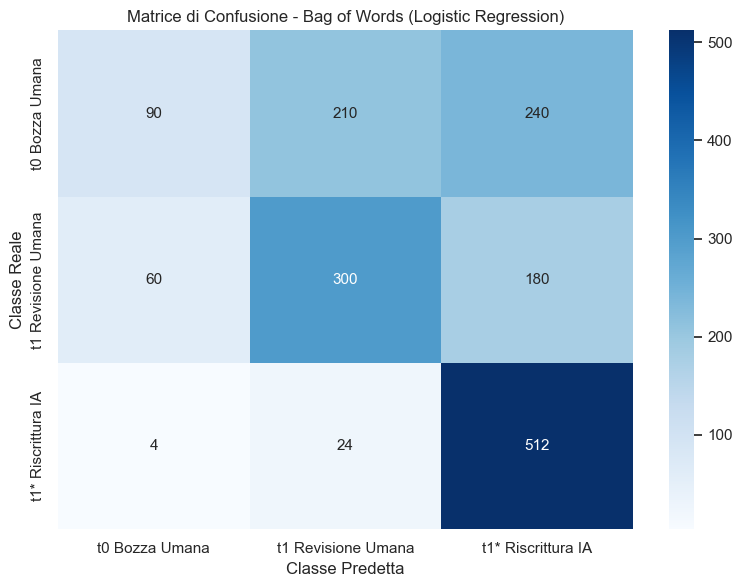

In [ ]:
print("=" * 70)
print("ESPERIMENTO 2: CLASSIFICAZIONE BAG OF WORDS (BoW)")
print("=" * 70)

# definizione locale di target_names per rendere la cella indipendente da quella di DistilBERT
target_names = ["t0 Bozza Umana", "t1 Revisione Umana", "t1* Riscrittura IA"]

# vettorializzazione del testo tramite CountVectorizer
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"[BoW] Dimensione Vocabolario Estratto: {X_train_bow.shape[1]} feature")

# logistic regression
clf_bow = LogisticRegression(max_iter=1000, random_state=42)
clf_bow.fit(X_train_bow, y_train)

# predizione e valutazione
y_pred_bow = clf_bow.predict(X_test_bow)

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE BAG OF WORDS (Logistic Regression)")
print("=" * 70)
print(classification_report(y_test, y_pred_bow, target_names=target_names))

# Matrice di Confusione BoW
cm_bow = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice di Confusione - Bag of Words (Logistic Regression)")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione Bag of Words (BoW) + Logistic Regression

La classificazione tramite la baseline Bag of Words abbinata alla regressione logistica registra un'**accuracy globale del 56%**. L'ispezione della matrice di confusione e del report di classificazione evidenzia il comportamento del modello basato sul conteggio diretto degli n-grammi:

* **Eccesso di Falsi Allarmi sulla classe $t_1^*$:** il modello mostra un'elevata recall del **95%** sulla classe $t_1^*$, individuando correttamente 512 campioni su 540 e generando soltanto 28 falsi negativi (4 scambiati per $t_0$ e 24 per $t_1$). Tuttavia, la precisione si arresta al **55%**: il classificatore tende ad assegnare la classe $t_1^*$ a molti testi appartenenti alle prime due classi, producendo **420 falsi positivi** (240 testi $t_0$ e 180 testi $t_1$ attribuiti erroneamente a $t_1^*$).
* **Forte Degradazione sulla classe $t_0$:** la sensibilità sulla classe $t_0$ crolla al **17%** (soli 90 testi riconosciuti correttamente su 540). La gran parte dei testi $t_0$ viene classificata erroneamente come $t_1$ (210 casi) o come $t_1^*$ (240 casi).
* **Sovrapposizione tra le Classi $t_0$ e $t_1$:** la classe $t_1$ ottiene una **recall del 56%** (300 testi individuati su 540). La confusione tra $t_0$ e $t_1$ dimostra come il conteggio delle frequenze non sia sufficiente per cogliere gli interventi di rifinitura e correzione apportati dall'uomo tra la prima e la seconda stesura.

L'approccio semplice BoW risente della presenza di n-grammi ricorrenti, sviluppando una marcata tendenza alla sovra-attribuzione verso la classe $t_1^*$ e mostrando limiti netti nel distinguere lo stile dell'uomo tra le classi $t_0$ e $t_1$.

### Ispezione dei Coefficienti e dei Marcatori Stilistici

Per comprendere i criteri di decisione della regressione logistica nella baseline BoW, si è resa necessaria un'analisi delle feature apprese. 

In questa sezione vengono estratti e ordinati i coefficienti del modello, isolando per ciascuna classe ($t_0$, $t_1$ e $t_1^*$) i 10 n-grammi con il peso decisionale maggiore. Questa ispezione permette di verificare quali indicatori lessicali o ortografici guidano la classificazione.

In [27]:
# recupero dei nomi delle feature dal vettorializzatore
feature_names = np.array(bow_vectorizer.get_feature_names_out())

print("=" * 70)
print("ANALISI DEI COEFFICIENTI BAG OF WORDS (TOP 10 PAROLE PER CLASSE)")
print("=" * 70)

# estrazione delle 10 parole con peso maggiore per ciascuna classe
for i, class_label in enumerate(target_names):
    top_indices = np.argsort(clf_bow.coef_[i])[-10:]
    top_words = feature_names[top_indices]
    top_weights = clf_bow.coef_[i][top_indices]
    
    df_top = pd.DataFrame({
        "Parola/N-gramma": top_words,
        "Peso (Coefficiente)": np.round(top_weights, 4)
    }).sort_values(by="Peso (Coefficiente)", ascending=False)
    
    print(f"\n---> Classe: [{class_label}]")
    print(df_top.to_string(index=False))

ANALISI DEI COEFFICIENTI BAG OF WORDS (TOP 10 PAROLE PER CLASSE)

---> Classe: [t0 Bozza Umana]
Parola/N-gramma  Peso (Coefficiente)
            don               0.8898
           risk               0.7931
             ed               0.7902
       everyday               0.7618
           able               0.7260
      questions               0.7149
        knowing               0.6704
     travelling               0.6640
         saving               0.6331
   driving know               0.6061

---> Classe: [t1 Revisione Umana]
Parola/N-gramma  Peso (Coefficiente)
           fail               0.7225
        reasons               0.6448
          lower               0.6164
    driven cars               0.5888
         chance               0.5019
      mentioned               0.4962
        dangers               0.4936
    improvement               0.4840
          stand               0.4791
         having               0.4791

---> Classe: [t1* Riscrittura IA]
Parola/N-gramma  Pes

### Interpretazione dei Coefficienti e dei Marcatori Stilistici

L'analisi dei coefficienti per ciascuna classe permette di avanzare alcune ipotesi:

* **Classe $t_0$ (Bozza Umana):** i pesi più elevati si concentrano su forme verbali spontanee (*knowing*), varianti di spelling britannico (*travelling* con doppia 'l') e possibili imperfezioni o contrazioni priva di punteggiatura (es. *don* in luogo di *don't*), suggerendo un registro iniziale più informale e meno revisionato.
* **Classe $t_1$ (Revisione Umana):** la classe appare associata a termini legati alla specificazione argomentativa e alla strutturazione delle cause (es. *fail*, *reasons*, *lower*, *chance*, *mentioned*), coerentemente con un processo umano di rifinitura concettuale del testo.
* **Classe $t_1^*$ (Riscrittura IA):** mostra una forte associazione con connettivi di transizione ad alto registro (es. *additionally*, *resulting*) e con la normalizzazione verso lo spelling americano (es. *traveling* con una sola 'l', in netto contrasto con la variante *travelling* maggiormente presente in $t_0$).

I coefficienti confermano che il modello cattura indicatori stilometrici reali. Tuttavia, l'uso delle frequenze grezze non ponderate in BoW limita l'accuracy, a causa dell'impatto dei termini ad alta frequenza legati al contenuto. Per isolare lo stile dal tema trattato, si procede alla ricalibrazione tramite vettorializzazione **TF-IDF**.

### Implementazione della Baseline Ricalibrata con TF-IDF

ESPERIMENTO 2 (RICALIBRATO): CLASSIFICAZIONE TF-IDF
[TF-IDF] Dimensione Vocabolario Estratto: 2000 feature

REPORT DI CLASSIFICAZIONE TF-IDF (Logistic Regression)
                    precision    recall  f1-score   support

    t0 Bozza Umana       0.68      0.44      0.54       540
t1 Revisione Umana       0.56      0.72      0.63       540
t1* Riscrittura IA       0.84      0.89      0.86       540

          accuracy                           0.69      1620
         macro avg       0.69      0.69      0.68      1620
      weighted avg       0.69      0.69      0.68      1620



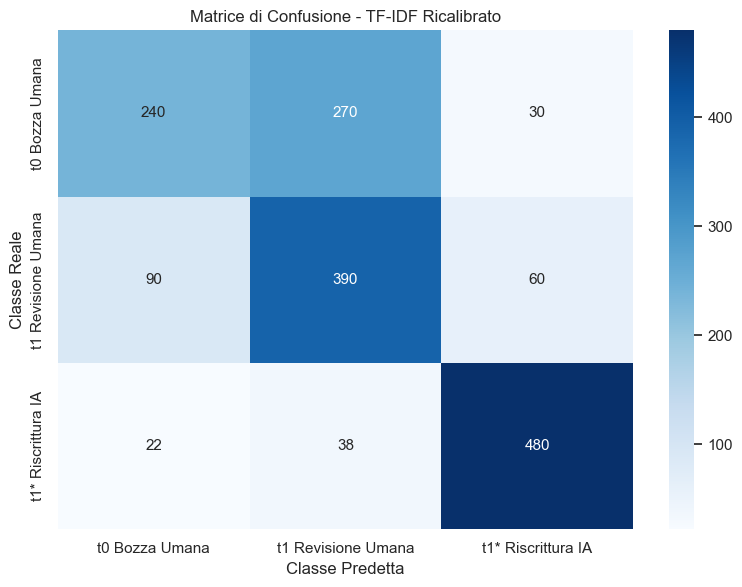

In [28]:
print("=" * 70)
print("ESPERIMENTO 2 (RICALIBRATO): CLASSIFICAZIONE TF-IDF")
print("=" * 70)

# 1. Vettorializzazione TF-IDF (solo unigrammi per escludere n-grammi di dominio)
tfidf_vectorizer = TfidfVectorizer(
    max_features=2000, 
    ngram_range=(1, 1), 
    stop_words="english",
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"[TF-IDF] Dimensione Vocabolario Estratto: {X_train_tfidf.shape[1]} feature")

# 2. Addestramento Logistic Regression
clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)

# 3. Predizione e Valutazione
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE TF-IDF (Logistic Regression)")
print("=" * 70)
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

# Matrice di Confusione TF-IDF
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice di Confusione - TF-IDF Ricalibrato")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione TF-IDF Ricalibrato

L'introduzione della vettorializzazione TF-IDF e focalizzazione sui soli unigrammi porta l'accuracy globale al **69%**, affermandosi come il modello più efficace dell'intero esperimento (rispetto al **56%** di BoW e al **48%** di DistilBERT).

L'ispezione della matrice di confusione evidenzia un netto miglioramento nel bilanciamento tra le classi:

* **Abbattimento dei Falsi Positivi sulla classe $t_1^*$:** a differenza della baseline BoW, TF-IDF riduce i falsi allarmi sulla classe $t_1^*$, portando la precision all'**84%** e mantenendo un'elevata recall dell'**89%** (480 testi identificati correttamente su 540). I falsi positivi scendono da 420 a soli 90 campioni totali (30 testi $t_0$ e 60 testi $t_1$ attribuiti erroneamente all'IA).

* **Recupero di Sensibilità sulla classe $t_0$:** la recall sulla classe $t_0$ sale dal **17%** al **44%** (240 testi riconosciuti correttamente su 540).

* **Elevata Rilevazione sulla classe $t_1$:** la classe $t_1$ ottiene la recall più alta tra le produzioni umane, raggiungendo il **72%** (390 testi individuati su 540). La confusione residua si registra tra le due stesure umane: 270 campioni $t_0$ vengono classificati come $t_1$, a conferma di come le due fasi condividono una continuità stilistica naturale rispetto alla riscrittura dell'IA.

### Conclusioni Esperimento 2

L'Esperimento 2 mette a confronto due modelli frequenziali basati su regressione logistica (**Bag of Words** e **TF-IDF Ricalibrato**) con un'architettura basata su Transformer (**DistilBERT**), per misurarne la capacità di classificare il testo tra bozza originale ($t_0$), revisione umana ($t_1$) e riscrittura sintetica dell'IA ($t_1^*$).

* **Supremazia del TF-IDF Ricalibrato (69% Accuracy):** l'approccio basato su `TfidfVectorizer` (soli unigrammi con scaling logaritmico `sublinear_tf=True`) si attesta come il miglior modello per questo task. Abbattendo l'impatto dei termini ad alta frequenza, TF-IDF riduce i falsi allarmi sulla classe $t_1^*$ portando la precision all'**84%** e la recall all'**89%**, pur mantenendo una buona capacita di distinzione sulla revisione umana $t_1$ (**72%** di recall).

* **Limiti del Conteggio Grezzo BoW (56% Accuracy):** la baseline BoW soffre la mancanza di ponderazione delle frequenze. Il modello mostra una forte tendenza alla sovra-attribuzione verso la riscrittura $t_1^*$ (recall del **95%**, ma precisione che crolla al **55%**), scambiando 420 testi scritti da umani per produzioni dell'IA e fallendo nel discriminare la prima stesura $t_0$ (**17%** di recall).

* **Impatto del Troncamento su DistilBERT (48% Accuracy):** il fine-tuning del Transformer basato sul contesto evidenzia un chiaro limite metodologico legato ai vincoli hardware. Il troncamento delle sequenze a 128 token costringe il modello ad analizzare unicamente l'incipit del saggio (~100 parole). Poiché i marcatori stilometrici della revisione si distribuiscono lungo l'intero elaborato, la perdita del 70% del testo porta la rete ad assegnare preventivamente la classe $t_1^*$ in caso di incertezza (recall del **94%** ma precisione del **47%**).

L'analisi dimostra che per compiti di classificazione su saggi di media e lunga estensione, una vettorializzazione globale ben calibrata (TF-IDF) supera un modello di Deep Learning.

---

## Esperimento 3 - Omogeneizzazione Lessicale e Sintattica

### Obiettivo
Questo terzo esperimento estende l'analisi alla varianza semantica, prendendo spunto dagli studi sull'omogeneizzazione generata dall'IA (es. ICLR 2026).

L'obiettivo è misurare il fenomeno della convergenza lessicale e semantica nei testi prodotti dagli LLM, applicando questa prospettiva a un nuovo dataset. Si vuole dimostrare che, sebbene gli LLM producano testi sintatticamente complessi, tendono a convergere verso un "vocabolario" standardizzato, appiattendo la ricchezza lessicale tipica di un gruppo di scrittori umani.

### Metriche per quantificare l'omogeneizzazione

Per quantificare l'omogeneizzazione vengono analizzate due mentriche complementari:

1. **Ricchezza Lessicale (Standardized Type-Token Ratio - STTR):** calcolata su una finestra standard di **150 token** per eliminare il bias legato alla lunghezza dei documenti.

2. **Diversità Sintattica e Strutturale (Distinct-N):** misura la quota di **N-grammi unici** ($N \in \{1, 2, 3\}$) sul totale delle sequenze.

### Dataset: HC3 Finance

Per questo esperimento utilizzeremo un sottoinsieme di **HC3**, focalizzato sul dominio finanziario (`Atharva07/hc3_finance`). 

Questo dataset raccoglie migliaia di domande di economia, per ciascuna delle quali abbiamo:
* **Risposta Umana:** caratterizzato da un possibile uso di gergo tecnico e da variazioni di tono tipiche dei forum umani.
* **Risposta IA (ChatGPT):** generata da IA, che potrebbe invece presentare un linguaggio più neutro e maggiormente uniforme.

Estraendo per ogni domanda esattamente una risposta umana e una sintetica, costruiremo un campione bilanciato (1:1).

In [61]:
print("=" * 70)
print("ESPERIMENTO 3: CARICAMENTO CORRETTO E CALCOLO STTR")
print("=" * 70)

# caricamento dataset
print("[INFO] Download dataset in corso...")
dataset = load_dataset("Atharva07/hc3_finance")
df_raw = pd.DataFrame(dataset['train'])

# estrazione testi
def safe_extract(val):
    if isinstance(val, list) and len(val) > 0:
        return str(val[0]).strip()
    elif isinstance(val, str) and len(val.strip()) > 0:
        return val.strip()
    return None

testi_umani = []
testi_ia = []

for idx, row in df_raw.iterrows():
    h_ans = safe_extract(row['human_answers'])
    ai_ans = safe_extract(row['chatgpt_answers'])
    
    if h_ans and ai_ans:
        testi_umani.append(h_ans)
        testi_ia.append(ai_ans)

# creazione dataframe bilanciato
df_exp3 = pd.DataFrame({
    "text": testi_umani + testi_ia,
    "label": ["Umano"] * len(testi_umani) + ["IA"] * len(testi_ia)
})

print(f"[DATA] Coppie estratte con successo: {len(testi_umani)}")
print(f"[DATA] Totale testi: {len(df_exp3)}")

ESPERIMENTO 3: CARICAMENTO CORRETTO E CALCOLO STTR
[INFO] Download dataset in corso...
[DATA] Coppie estratte con successo: 3104
[DATA] Totale testi: 6208


### Fase 1: Calcolo della Ricchezza Lessicale (TTR)

Per quantificare la varietà del vocabolario utilizzato nei due insiemi, calcoleremo il **Type-Token Ratio (TTR)**. Questa metrica mette in rapporto il numero di parole uniche (Type) con il numero totale di parole (Token) presenti in un documento:

$$TTR = \frac{\text{Type}}{\text{Token}}$$

* **Valori più alti** indicano un testo lessicalmente ricco e variegato, tipico della scrittura umana (che include gergo, sinonimi e metafore).
* **Valori più bassi** indicano un testo ripetitivo e conservativo.

Per evitare che testi più lunghi penalizzino il punteggio, si adotta lo Standardized TTR (STTR) fisso sui primi 150 token di ogni risposta.

### Implentazione Codice

[BIAS] Testi umani validi: 1415/3104 (45.6%)
[BIAS] Testi IA validi: 2618/3104 (84.3%)
[INFO] Testi totali rimasti (≥ 150 token): 4033 su 6208


,mean,std,min,max,count
label,,,,,
IA,0.5197,0.0640,0.2733,0.6867,2618
Umano,0.6158,0.0598,0.3267,0.7800,1415


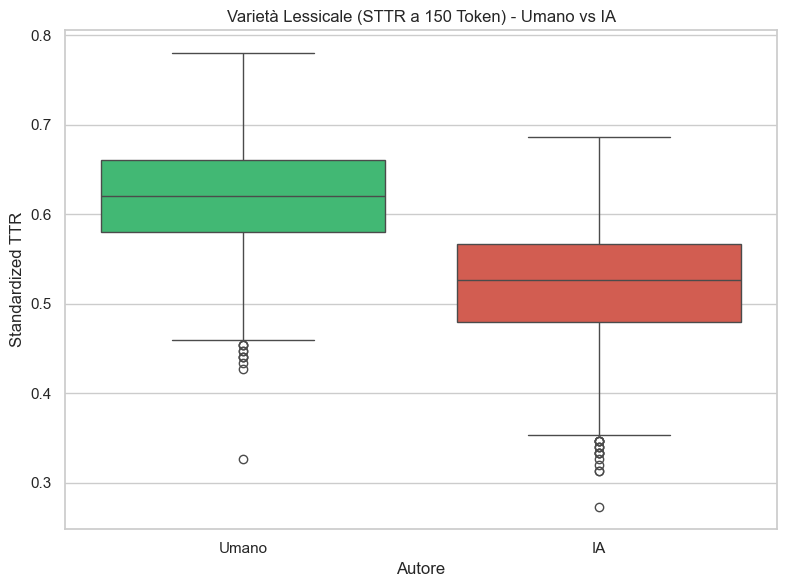

In [ ]:
MAX_TOKENS = 150

def get_sttr(text, MAX_TOKENS):
    tokens = re.findall(r'\b\w+\b', text.lower())
    if len(tokens) < MAX_TOKENS:
        return None  # scarto testi con meno di 150 parole
    
    tokens_sub = tokens[:MAX_TOKENS]
    types = set(tokens_sub)
    return len(types) / len(tokens_sub)

df_exp3["STTR"] = df_exp3["text"].apply(lambda x: get_sttr(x, MAX_TOKENS))

# conteggio dei testi con almeno 150 token
human_tot = len(df_exp3[df_exp3["label"] == "Umano"])
ai_tot = len(df_exp3[df_exp3["label"] == "IA"])
human_surv = df_exp3[df_exp3["label"] == "Umano"]["STTR"].notna().sum()
ai_surv = df_exp3[df_exp3["label"] == "IA"]["STTR"].notna().sum()

print(f"[BIAS] Testi umani validi: {human_surv}/{human_tot} ({(human_surv/human_tot)*100:.1f}%)")
print(f"[BIAS] Testi IA validi: {ai_surv}/{ai_tot} ({(ai_surv/ai_tot)*100:.1f}%)")

df_clean = df_exp3.dropna(subset=["STTR"]).copy()
print(f"[INFO] Testi totali rimasti (≥ {MAX_TOKENS} token): {len(df_clean)} su {len(df_exp3)}")

stats_ttr = df_clean.groupby("label")["STTR"].agg(["mean", "std", "min", "max", "count"]).round(4)
display(stats_ttr)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x="label", y="STTR", hue="label", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("Varietà Lessicale (STTR a 150 Token) - Umano vs IA")
plt.xlabel("Autore")
plt.ylabel("Standardized TTR")
plt.tight_layout()
plt.show()

**Nota**: L'applicazione della soglia sul numero di token fa emergere una forte asimmetria strutturale. Solo circa il **46%** circa dei testi umani raggiunge i 150 token, contro l'84% di quelli generati dall'IA. Oltre a confermare che l'IA genera testi sistematicamente più lunghi, questo filtro introduce un bias: il calcolo dello **STTR** finirà per confrontare l'intero spettro produttivo dell'IA esclusivamente con la parte dei testi umani più lunghi.

### Analisi dei Risultati: Type-Token Ratio (STTR)

L'analisi della ricchezza lessicale, calcolata sui primi 150 token, conferma l'ipotesi di omogeneizzazione del vocabolario nell'IA:

* **Compressione Lessicale dell'IA:** il modello linguistico presenta un STTR medio di $0.52$, indicando una spiccata tendenza a riutilizzare lo stesso set di parole e congiunzioni.
* **Varianza Umana:** gli autori umani mantengono una media nettamente superiore (circa $0.62$) e raggiungono picchi di varietà molto più alti (fino a un massimo di $0.78$), un valore che l'IA non riesce a sfiorare (fermandosi a un massimo di $0.69$).
* **Significatività:** il boxplot evidenzia come l'intera distribuzione generata dall'IA sia traslata verso il basso. Il crollo della ricchezza lessicale media dell'IA rispetto all'umano è del **-15,6%**. Nonostante il dominio finanziario sia scritto con un gergo specifico, gli umani riescono a esprimere i concetti con una maggiore diversità di vocaboli rispetto al pattern di ChatGPT.

## Fase 2: Diversità Sintattica e Strutturale (Distinct-N)

Per verificare se l'omogeneizzazione riguardi anche le **strutture di frase** e le **combinazioni di parole**, è stata calcolata la metrica **Distinct-N** per:

1. **N = 1** → unigrammi
2. **N = 2** → bigrammi
3. **N = 3** → trigrammi

Per evitare distorsioni statistiche legate alle dimensioni complessive dei due dataset (in linea con la Legge di Heaps, secondo cui la varietà lessicale diminuisce all'aumentare della lunghezza del testo), la metrica non è calcolata sull'intero corpus,ma valutata per singola risposta (sempre sulla finestra standard di 150 token), estraendone successivamente la media aritmetica.

La formula è:

$$\text{Distinct-N} = \frac{\text{Numero di N-grammi Unici}} {\text{Numero Totale di N-grammi}}$$

In [ ]:
def calculate_distinct_n_per_doc(texts, n=2):
    scores = []
    for t in texts:
        # dividiamo il testo in frasi separate. Così facciamo in modo che l'ultima parola della frase 1 e la prima parola della frase 2 non si uniscano per sbaglio.
        sentences = sent_tokenize(t.lower())
        
        ngrams = []
        for sentence in sentences:
            # tokenizziamo la singola frase rimuovendo la punteggiatura
            tokens = [w for w in word_tokenize(sentence) if w.isalnum()]
            
            # estraiamo gli n-grammi solo all'interno della stessa frase
            if len(tokens) >= n:
                sentence_ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
                ngrams.extend(sentence_ngrams)
        
        # calcoliamo la varietà di parole per singolo testo. Dividiamo le coppie uniche per il totale delle coppie trovate
        if ngrams:
            score = len(set(ngrams)) / len(ngrams)
            scores.append(score)
    
    if not scores:
        return 0.0
    return sum(scores) / len(scores)

testi_clean_human = df_clean[df_clean["label"] == "Umano"]["text"].tolist()
testi_clean_ai = df_clean[df_clean["label"] == "IA"]["text"].tolist()

print("=" * 70)
print("ANALISI DISTINCT-N (MEDIA PER SINGOLA RISPOSTA)")
print("=" * 70)

results = []
for n in [1, 2, 3]:
    d_human = calculate_distinct_n_per_doc(testi_clean_human, n=n)
    d_ai = calculate_distinct_n_per_doc(testi_clean_ai, n=n)
    drop = ((d_human - d_ai) / d_human) * 100
    results.append({
        "N-Gram": f"Distinct-{n}", 
        "Umano": round(d_human, 4), 
        "IA": round(d_ai, 4), 
        "Crollo IA (%)": f"-{round(drop, 1)}%"
    })

df_distinct = pd.DataFrame(results)
display(df_distinct)

ANALISI DISTINCT-N (MEDIA PER SINGOLA RISPOSTA)


,N-Gram,Umano,IA,Crollo IA (%)
0,Distinct-1,0.5297,0.4662,-12.0%
1,Distinct-2,0.8989,0.8037,-10.6%
2,Distinct-3,0.9697,0.9020,-7.0%


In [66]:
print("=" * 70)
print("ESTRAZIONE N-GRAMMI PIÙ FREQUENTI (UMANO VS IA)")
print("=" * 70)

def estrai_top_ngrams(texts, n=2, top_k=5):
    # non rimuoviamo le stop words per catturare le formule sintattiche
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None, token_pattern=r'\b\w+\b').fit(texts)
    bag = vec.transform(texts)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=[f"Top {n}-Grammi", "Frequenza"])

# estrazione bigrammi e trigrammi
df_bi_human = estrai_top_ngrams(testi_clean_human, n=2, top_k=5)
df_bi_ai = estrai_top_ngrams(testi_clean_ai, n=2, top_k=5)
df_bi_comp = pd.concat([df_bi_human.add_suffix(' Umano'), df_bi_ai.add_suffix(' IA')], axis=1)

df_tri_human = estrai_top_ngrams(testi_clean_human, n=3, top_k=5)
df_tri_ai = estrai_top_ngrams(testi_clean_ai, n=3, top_k=5)
df_tri_comp = pd.concat([df_tri_human.add_suffix(' Umano'), df_tri_ai.add_suffix(' IA')], axis=1)

print("\n--- Confronto Bigrammi ---")
display(df_bi_comp)

print("\n--- Confronto Trigrammi ---")
display(df_tri_comp)

ESTRAZIONE N-GRAMMI PIÙ FREQUENTI (UMANO VS IA)

--- Confronto Bigrammi ---


,Top 2-Grammi Umano,Frequenza Umano,Top 2-Grammi IA,Frequenza IA
0,of the,2063,of the,3782
1,if you,1681,if you,2761
2,in the,1585,it is,2394
3,you can,1087,in the,2180
4,to the,984,it s,2127



--- Confronto Trigrammi ---


,Top 3-Grammi Umano,Frequenza Umano,Top 3-Grammi IA,Frequenza IA
0,you don t,244,it s important,1258
1,if you are,223,s important to,1239
2,a lot of,176,a good idea,899
3,you need to,176,if you are,887
4,be able to,173,good idea to,856


### Interpretazione dei Risultati Distinct-N

L'estrazione degli n-grammi ci dimostra che:

1. **Unigrammi (Distinct-1: -12,0%)**: la percentuale media di vocaboli unici scende da $0,5297$ (umani) a $*0,4662$ (IA). Il modello linguistico ricorre a un vocabolario complessivamente più ristretto, ripetendo gli stessi termini all'interno dello stesso documento.
2. **Bigrammi (Distinct-2: -10,6%)**: la varietà delle coppie di parole si riduce da $0,8989$ a $0,8037$. Nelle risposte sintetiche, si osserva una presenza massiccia di bigrammi funzionali e connettivi (es. *"of the"* con 3.782 occorrenze vs 2.063 umane, *"if you"* 2.761 vs 1.681 umane, *"it is"* 2.394 vs 1.585 umane).
3. **Trigrammi (Distinct-3: -7,0%)**: la varietà dei trigrammi scende da $0,9697$ a $0,9020$. L'analisi sui trigrammi rivela la presenza di **formule prescrittive e di consiglio molto ricorrenti**: l'IA costruisce le sue spiegazioni su strutture fisse come *"it s important"* (1.258 occorrenze), *"s important to"* (1.239), *"a good idea"* (899) e *"good idea to"* (856). Al contrario, il trigramma scritto dall'uomo più frequente (*"you don t"*) conta sole 244 occorrenze, dimostrando una dispersione sintattica molto più ampia.

### Conclusioni dell'Esperimento 3

L'**Esperimento 3** dimostra che l'omogeneizzazione generata dai modelli linguistici non riguarda la perdita di accuratezza nei contenuti, quanto piuttosto un solido **appiattimento della diversità stilistica, lessicale e sintattica**:

* **Standardizzazione delle formule di supporto:** ChatGPT tende a strutturare l'informazione attraverso un set rigido di formule introduttive e prescrittive (*"it's important to"*, *"it's a good idea to"*), del tutto assenti tra i primi posti della scrittura umana.
* **Firma linguistica ridondante:** il calo dello **STTR (-15,6% sulla media per documento)** e del **Distinct-2 (-10,6%)** riflette una espansione testuale basata sulla ripetizione dello stesso repertorio di connettivi e bigrammi funzionali.
* **Effetto della lunghezza dei testi:** l'applicazione del filtro della lunghezza minima (150 token) mette in luce un'importante asimmetria strutturale. L'**84,3%** delle risposte IA (2.618 su 3.104) supera questa soglia, contro soltanto il **45,6%** di quelle umane (1.415 su 3.104). Questo dimostra che i testi dell'IA appaiono più complessi soprattutto perché sono più lunghi; tuttavia, confrontando testi della stessa estensione, la scrittura dell'IA si rivela molto più ripetitiva e prevedibile.

In sintesi, i risultati mostrano quindi un compromesso tra la capacità degli **LLM** di produrre testi coerenti e strutturati e la varietà dello stile utilizzato. Gli **LLM** garantiscono elevata chiarezza ed efficienza espositiva, ma al prezzo di sacrificare la naturale variabilità espressiva, spontaneità e l'imprevedibilità sintattica della produzione umana.